# Exploratory Data Analysis (EDA)

## Import Library

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from utils import load_analytics_dataset, show_3_distribution_charts, show_3_sns_charts
import warnings
warnings.filterwarnings('ignore')

## Load Feature Data

In [7]:
%%time
df = load_analytics_dataset()

CPU times: user 964 ms, sys: 53.1 ms, total: 1.02 s
Wall time: 1.02 s


### Show columns

In [8]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'hour', 'minute',
       'day_of_month', 'month', 'year', 'day_of_week', 'time_int',
       'session_progress', 'day_high', 'day_low', 'day_close', 'day_open',
       'day_volume', 'day_pivot', 'prev_day_close', 'prev_day_open',
       'prev_day_high', 'prev_day_low', 'prev_day_volume', 'prev_day_pivot',
       'body', 'height', 'upwick', 'lowwick', 'upwick_rate', 'lowwick_rate',
       'body_rate', 'clv', 'cbr', 'vbr', 'ibs', 'wick_imbalance',
       'upwick_ratio', 'color', 'ema_fast', 'ema_slow', 'rsi', 'rsi_slope',
       'tsi', 'roc_close', 'close_zscore', 'efficiency_ratio', 'macd',
       'macd_hist', 'macd_signal', 'ppo', 'ppo_hist', 'ppo_signal',
       'ulcer_index', 'cmo', 'roc_skew', 'roc_kurt', 'mb', 'std', 'ub', 'lb',
       'volume_avg', 'volume_zscore', 'close_lag1', 'open_lag1', 'high_lag1',
       'low_lag1', 'volume_lag1', 'body_lag1', 'upwick_lag1', 'lowwick_lag1',
       'ibs_lag1', 'rsi_lag1', 'ema_fast_lag1', 'ema_

### Thống kê cơ bản

In [9]:
df.describe()

,Open,High,Low,Close,Volume,hour,minute,day_of_month,month,year,...,vwap,atr,adx,dm,eom,direction,streak,custom_001,custom_002,couple_cs_signal
count,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,...,88026.000000,88026.000000,88026.000000,88026.000000,86184.000000,88026.000000,88026.000000,88026.000000,88026.000000,0.0
mean,1166.008474,1166.993196,1165.013523,1166.011180,3984.186434,11.184127,24.185127,15.939245,6.731204,2021.724400,...,1165.959804,2.099013,23.366359,0.010814,-0.000010,-0.063186,-0.188399,0.047394,0.051103,NaN
std,269.239042,269.528032,268.951125,269.242234,3693.198057,1.858889,16.943597,8.660265,3.400652,2.104711,...,269.180673,1.376279,10.356609,1.834017,0.002311,0.998007,1.718283,1.391000,0.571411,NaN
min,565.000000,570.400000,560.100000,565.000000,1.000000,9.000000,0.000000,1.000000,1.000000,2018.000000,...,581.900000,0.275979,5.347156,-55.750000,-0.198200,-1.000000,-43.000000,-11.006944,-4.000000,NaN
25%,915.600000,916.300000,915.100000,915.700000,1825.000000,10.000000,10.000000,8.000000,4.000000,2020.000000,...,915.597597,1.210917,15.491805,-0.550000,-0.000262,-1.000000,-1.000000,-0.554585,-0.456311,NaN
50%,1169.800000,1170.900000,1168.500000,1169.750000,3103.000000,11.000000,20.000000,16.000000,7.000000,2022.000000,...,1169.929411,1.722232,21.261380,0.000000,0.000000,-1.000000,0.000000,0.067686,0.071429,NaN
75%,1337.800000,1338.500000,1337.000000,1337.800000,5094.000000,13.000000,40.000000,23.000000,10.000000,2024.000000,...,1337.607986,2.519476,29.316387,0.600000,0.000275,1.000000,0.000000,0.729253,0.571429,NaN
max,2038.000000,2041.000000,2036.500000,2038.000000,251304.000000,14.000000,55.000000,31.000000,12.000000,2025.000000,...,2030.974651,14.911390,73.457375,78.950000,0.421194,1.000000,13.000000,11.524164,3.333333,NaN


### Dataframe Information

In [10]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 88026 entries, 2018-08-20 09:05:00 to 2025-11-04 14:45:00
Data columns (total 99 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Open                88026 non-null  float64
 1   High                88026 non-null  float64
 2   Low                 88026 non-null  float64
 3   Close               88026 non-null  float64
 4   Volume              88026 non-null  int64  
 5   hour                88026 non-null  int64  
 6   minute              88026 non-null  int64  
 7   day_of_month        88026 non-null  int64  
 8   month               88026 non-null  int64  
 9   year                88026 non-null  int64  
 10  day_of_week         88026 non-null  int64  
 11  time_int            88026 non-null  int64  
 12  session_progress    88026 non-null  float64
 13  day_high            88026 non-null  float64
 14  day_low             88026 non-null  float64
 15  day_close           88026 non

In [11]:
df.isnull().sum()

Open                    0
High                    0
Low                     0
Close                   0
Volume                  0
                    ...  
high_ub_pattern         0
low_lb_pattern          0
couple_cs_signal    88026
ema_cross_signal    87486
allow_entry         20177
Length: 99, dtype: int64

<Axes: >

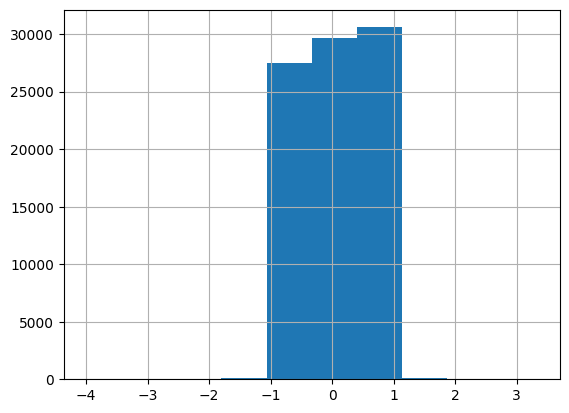

In [12]:
df['custom_002'].hist()


### Correlation Matrix

In [14]:
df_numeric = df.select_dtypes(include='number')
df_numeric.corr()

,Open,High,Low,Close,Volume,hour,minute,day_of_month,month,year,...,vwap,atr,adx,dm,eom,direction,streak,custom_001,custom_002,couple_cs_signal
Open,1.000000,0.999986,0.999985,0.999978,0.118442,-0.000122,0.000135,0.002431,0.028570,0.674605,...,0.999865,0.412472,-0.017458,0.006495,-0.002473,0.007461,0.021631,0.045341,0.025024,NaN
High,0.999986,1.000000,0.999974,0.999987,0.120290,0.000495,-0.000071,0.002451,0.028552,0.674713,...,0.999855,0.414507,-0.017207,0.008738,-0.000360,0.009701,0.022998,0.045251,0.025088,NaN
Low,0.999985,0.999974,1.000000,0.999988,0.116483,-0.000753,0.000356,0.002376,0.028605,0.674544,...,0.999843,0.410419,-0.017706,0.009289,-0.000125,0.009448,0.022905,0.046350,0.025917,NaN
Close,0.999978,0.999987,0.999988,1.000000,0.118374,-0.000121,0.000145,0.002409,0.028563,0.674621,...,0.999843,0.412483,-0.017469,0.010197,0.000720,0.011388,0.023942,0.046114,0.025833,NaN
Volume,0.118442,0.120290,0.116483,0.118374,1.000000,0.253419,-0.025609,0.022163,0.005070,0.214890,...,0.119017,0.384878,-0.011969,-0.015689,-0.024143,0.015116,0.020464,-0.071017,-0.060655,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
direction,0.007461,0.009701,0.009448,0.011388,0.015116,-0.014904,-0.025947,-0.005615,-0.006695,0.007004,...,0.007892,0.014426,0.004769,0.307959,0.164036,1.000000,0.553573,0.058609,0.083878,NaN
streak,0.021631,0.022998,0.022905,0.023942,0.020464,0.025717,0.006351,-0.010870,-0.001530,0.003922,...,0.018628,0.013003,-0.003734,0.338678,0.175728,0.553573,1.000000,0.082232,0.128219,NaN
custom_001,0.045341,0.045251,0.046350,0.046114,-0.071017,-0.000028,-0.000287,-0.048637,-0.002966,0.022603,...,0.038255,-0.118450,-0.038522,0.167612,0.109049,0.058609,0.082232,1.000000,0.814233,NaN
custom_002,0.025024,0.025088,0.025917,0.025833,-0.060655,0.006566,0.001632,-0.023213,-0.021059,0.011653,...,0.019250,-0.101610,0.040264,0.160248,0.079260,0.083878,0.128219,0.814233,1.000000,NaN


### Redundancy

In [15]:
corr_matrix = df.select_dtypes(include='number').corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
redundancy = [col for col in upper.columns if any(upper[col] > 0.9)]

In [16]:
redundancy

['High',
 'Low',
 'Close',
 'time_int',
 'session_progress',
 'day_high',
 'day_low',
 'day_close',
 'day_open',
 'day_pivot',
 'prev_day_close',
 'prev_day_open',
 'prev_day_high',
 'prev_day_low',
 'prev_day_pivot',
 'cbr',
 'ema_fast',
 'ema_slow',
 'tsi',
 'macd_signal',
 'ppo_signal',
 'cmo',
 'mb',
 'ub',
 'lb',
 'close_lag1',
 'open_lag1',
 'high_lag1',
 'low_lag1',
 'rsi_lag1',
 'ema_fast_lag1',
 'ema_slow_lag1',
 'vwap']